In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr

smn_df = pd.read_csv('smn_historico.csv')

provincias_pampeana = [
    'BUENOS AIRES',
    'CORDOBA',
    'SANTA FE',
    'ENTRE RIOS',
    'LA PAMPA',
    'CAPITAL FEDERAL'
]

pampeana_df = smn_df[smn_df['provincia'].isin(provincias_pampeana)].copy()

columnas_numericas = ['altura', 'LAT_decimal', 'LON_decimal', 'prec_sup_1mm',
                      'humedad', 'nubosidad', 'prec_mm', 'temp',
                      'temp_max', 'temp_min', 'viento']
for columna in columnas_numericas:
    pampeana_df[columna] = pd.to_numeric(pampeana_df[columna], errors='coerce')

print(f'Dataset original: {smn_df.shape}')
print(f'Región Pampeana: {pampeana_df.shape}')
print('Provincias encontradas:')
print(sorted(pampeana_df['provincia'].dropna().unique()))

Dataset original: (1176, 16)
Región Pampeana: (480, 16)
Provincias encontradas:
['BUENOS AIRES', 'CAPITAL FEDERAL', 'CORDOBA', 'ENTRE RIOS', 'LA PAMPA', 'SANTA FE']


In [4]:
# 1. Cantidad de estaciones meteorológicas
cantidad_estaciones = pampeana_df['estacion'].nunique()

# 2. Altura media
altura_media = pampeana_df.drop_duplicates('estacion')['altura'].mean()

# 3 y 4. Temperatura media y desvío estándar
temperatura_media = pampeana_df['temp'].mean()
temperatura_desvio = pampeana_df['temp'].std()

# 5. Mes con mayor precipitación media
orden_meses = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun',
               'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']
precipitacion_por_mes = pampeana_df.groupby('mes_txt', observed=True)['prec_mm'].mean()
precipitacion_por_mes = precipitacion_por_mes.reindex(orden_meses)
mes_mayor_precipitacion = precipitacion_por_mes.idxmax()

# 6. Provincia con mayor temperatura media
temperatura_por_provincia = pampeana_df.groupby('provincia', observed=True)['temp'].mean().sort_values(ascending=False)
provincia_mayor_temperatura = temperatura_por_provincia.idxmax()

# 7. Outliers mediante IQR
Q1 = pampeana_df[['temp', 'prec_mm']].quantile(0.25)
Q3 = pampeana_df[['temp', 'prec_mm']].quantile(0.75)
IQR = Q3 - Q1
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR
outliers_iqr = {
    columna: int(((pampeana_df[columna] < limite_inferior[columna]) |
                  (pampeana_df[columna] > limite_superior[columna])).sum())
    for columna in ['temp', 'prec_mm']
}

# 8. Correlación de Spearman entre altura y temperatura media por estación
estacion_df = pampeana_df.groupby(['estacion', 'altura'], as_index=False, observed=True)['temp'].mean()
rho, p_valor = spearmanr(estacion_df['altura'], estacion_df['temp'])

# 9. Eta cuadrado entre provincia y precipitación
media_general = pampeana_df['prec_mm'].mean()
medias_por_provincia = pampeana_df.groupby('provincia', observed=True)['prec_mm'].mean()
conteos_por_provincia = pampeana_df.groupby('provincia', observed=True)['prec_mm'].count()
suma_cuadrados_entre = (conteos_por_provincia * (medias_por_provincia - media_general) ** 2).sum()
suma_cuadrados_total = ((pampeana_df['prec_mm'] - media_general) ** 2).sum()
eta_cuadrado = suma_cuadrados_entre / suma_cuadrados_total

print('RESPUESTAS DE LA REGIÓN PAMPEANA')
print(f'1. Estaciones meteorológicas: {cantidad_estaciones}')
print(f'2. Altura media: {altura_media:.2f} m')
print(f'3. Temperatura media: {temperatura_media:.2f} °C')
print(f'4. Desvío estándar de temperatura: {temperatura_desvio:.2f} °C')
print(f'5. Mayor precipitación media: {mes_mayor_precipitacion}')
print(f'6. Provincia con mayor temperatura media: {provincia_mayor_temperatura}')
print(f'7. Outliers por IQR: {outliers_iqr}')
print(f'8. Spearman altura-temperatura: rho={rho:.3f}, p={p_valor:.4f}')
print(f'9. Eta cuadrado provincia-precipitación: {eta_cuadrado:.3f}')

print('\nPrecipitación media por mes:')
display(precipitacion_por_mes.to_frame('prec_mm_media'))

print('\nTemperatura media por provincia:')
display(temperatura_por_provincia.to_frame('temp_media'))

RESPUESTAS DE LA REGIÓN PAMPEANA
1. Estaciones meteorológicas: 40
2. Altura media: 134.55 m
3. Temperatura media: 16.55 °C
4. Desvío estándar de temperatura: 5.19 °C
5. Mayor precipitación media: Mar
6. Provincia con mayor temperatura media: SANTA FE
7. Outliers por IQR: {'temp': 0, 'prec_mm': 0}
8. Spearman altura-temperatura: rho=-0.175, p=0.2815
9. Eta cuadrado provincia-precipitación: 0.078

Precipitación media por mes:


,prec_mm_media
mes_txt,
Ene,112.500000
Feb,112.679487
Mar,113.372500
Abr,97.012500
May,55.330000
Jun,35.870000
Jul,36.089474
Ago,40.867500
Sep,55.138462



Temperatura media por provincia:


,temp_media
provincia,
SANTA FE,18.480000
ENTRE RIOS,18.402778
CAPITAL FEDERAL,18.066667
CORDOBA,17.327083
LA PAMPA,15.962500
BUENOS AIRES,15.364135


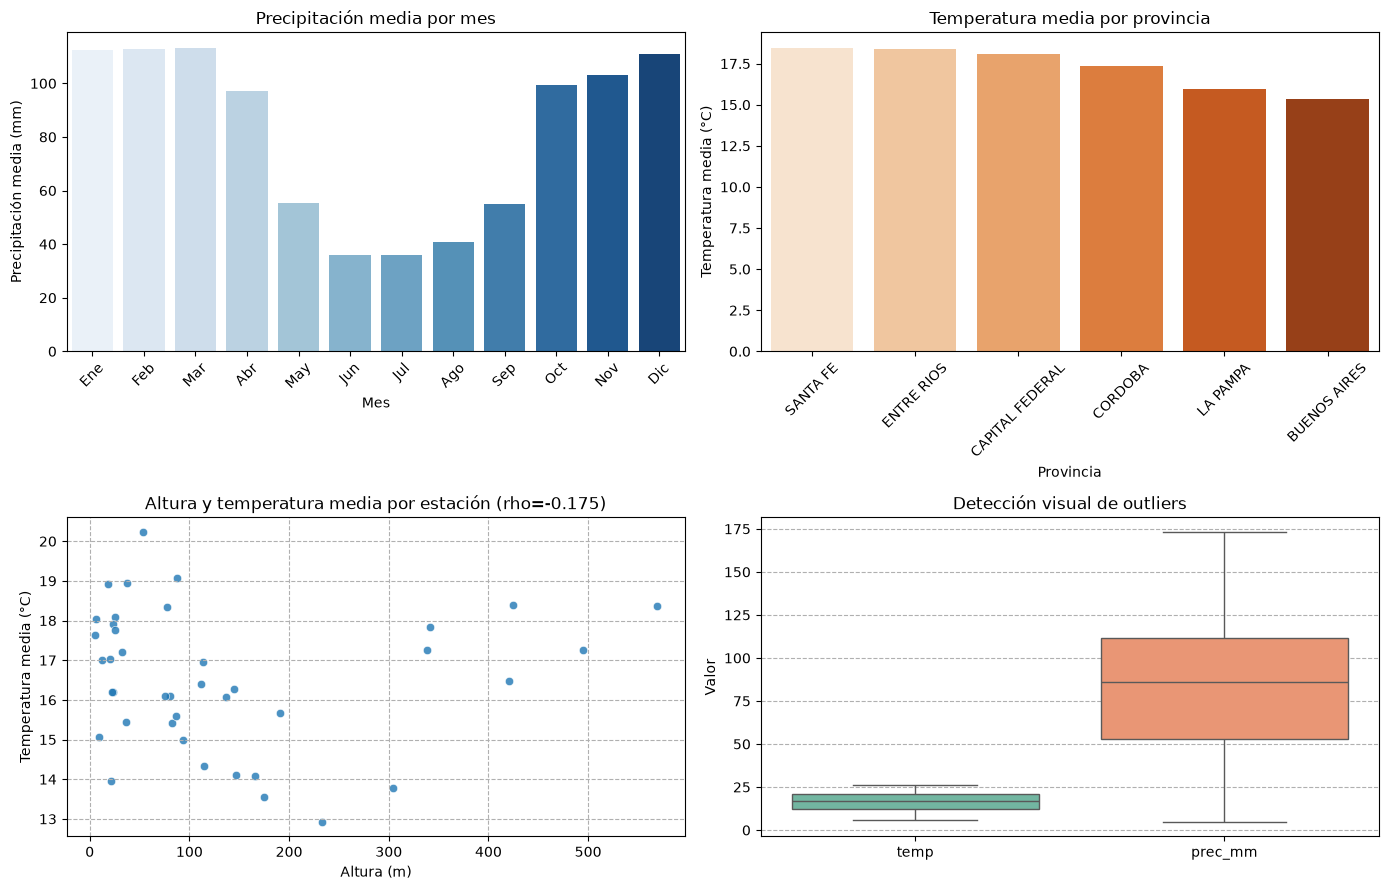

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

sns.barplot(x=precipitacion_por_mes.index, y=precipitacion_por_mes.values,
            hue=precipitacion_por_mes.index, palette='Blues', legend=False, ax=axes[0, 0])
axes[0, 0].set_title('Precipitación media por mes')
axes[0, 0].set_xlabel('Mes')
axes[0, 0].set_ylabel('Precipitación media (mm)')
axes[0, 0].tick_params(axis='x', rotation=45)

sns.barplot(x=temperatura_por_provincia.index, y=temperatura_por_provincia.values,
            hue=temperatura_por_provincia.index, palette='Oranges', legend=False, ax=axes[0, 1])
axes[0, 1].set_title('Temperatura media por provincia')
axes[0, 1].set_xlabel('Provincia')
axes[0, 1].set_ylabel('Temperatura media (°C)')
axes[0, 1].tick_params(axis='x', rotation=45)

sns.scatterplot(data=estacion_df, x='altura', y='temp', alpha=0.8, ax=axes[1, 0])
axes[1, 0].set_title(f'Altura y temperatura media por estación (rho={rho:.3f})')
axes[1, 0].set_xlabel('Altura (m)')
axes[1, 0].set_ylabel('Temperatura media (°C)')
axes[1, 0].grid(ls='--')

sns.boxplot(data=pampeana_df[['temp', 'prec_mm']], palette='Set2', ax=axes[1, 1])
axes[1, 1].set_title('Detección visual de outliers')
axes[1, 1].set_ylabel('Valor')
axes[1, 1].grid(axis='y', ls='--')

plt.tight_layout()
plt.show()

## Caracterización climática: Santa Fe

La provincia seleccionada es **Santa Fe**, perteneciente a la Región Pampeana. Según los datos analizados, presenta una temperatura media de **18,48 °C**, con valores entre 8,8 °C y 26,4 °C. La precipitación media es de aproximadamente **87,04 mm**, mientras que la humedad relativa media alcanza el **73,86%**. La nubosidad media es de **3,42** y el viento presenta una velocidad media de **12,54**. En conjunto, estos valores caracterizan un clima templado, con humedad relativamente elevada y precipitaciones distribuidas durante el año, aunque con mayores registros durante los meses cálidos.